In [1]:
## Langmuir_wave.py
# Example of plasma oscillations of electrons
from jaxincell import plot
from jaxincell import simulation, diagnostics
import jax.numpy as jnp
from jax import block_until_ready

c:\ProgramData\miniconda3\envs\plasma_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Length of the simulation box: 99.00000000000001 Debye lengths or 3.5001785668734104 Skin Depths
Density of electrons: 345970244927349.5 m^-3
Electron temperature: 638.7486896859265 eV
Ion temperature / Electron temperature: 1e-09
Debye length: 0.0101010101010101 m
Skin depth: 0.2856997095703222 m
Wavenumber * Debye length: 0.06346651825433926
Pseudoparticles per cell: 90.9090909090909
Pseudoparticle weight: 115323414975.78317
Steps at each plasma frequency: 18.856180831641268
Total time: 53.033008588991066 / plasma frequency
Number of particles on a Debye cube: 356560446.75646317
Relativistic gamma factor: Maximum 1.1194175900880585, Average 1.0309552358599081
Charge x External electric field x Debye Length / Temperature: 0.0



Running for 1,000 iterations: 100%|██████████| 1000/1000 [00:01<00:00, 530.55it/s]


Dominant FFT frequency (f): 994568027.5390745 Hz
Plasma frequency (w_p):     1049327136.0018971 Hz
Error: 5.22%


MovieWriter stderr:
[AVFormatContext @ 0000020DE5012200] Unable to choose an output format for 'langmuir_jaxincell'; use a standard extension for the filename or specify the format manually.
[out#0 @ 0000020DE0D21100] Error initializing the muxer for langmuir_jaxincell: Invalid argument
Error opening output file langmuir_jaxincell.
Error opening output files: Invalid argument

c:\ProgramData\miniconda3\envs\plasma_env\Lib\site-packages\jaxincell\_plot.py:872: RuntimeWarning: Failed to save video. This usually means ffmpeg is not installed or not on PATH.
Error was: Command '['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '2250x900', '-pix_fmt', 'rgba', '-framerate', '30', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'h264_nvenc', '-vf', 'scale=trunc(iw/2)*2:trunc(ih/2)*2', '-pix_fmt', 'yuv420p', '-movflags', '+faststart', '-tag:v', 'avc1', '-y', 'langmuir_jaxincell']' returned non-zero exit status 4294967274.
Install ffmpeg (e.g. `conda install -c conda-forge ffmpeg`) and 

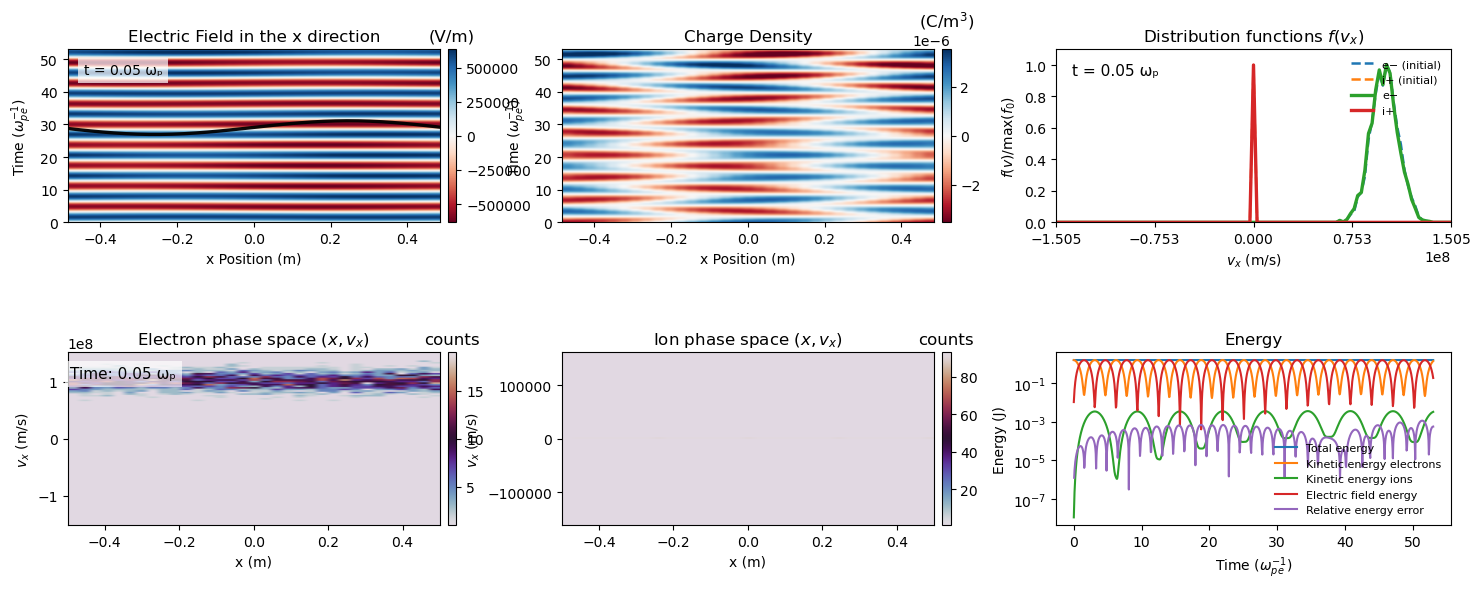

: 

In [ ]:
input_parameters = {
"length"                       : 1,  # dimensions of the simulation box in (x, y, z)
"amplitude_perturbation_x"     : 0.01,  # amplitude of sinusoidal perturbation in x
"wavenumber_electrons_x": 1, # Wavenumber of sinusoidal electron density perturbation in x (factor of 2pi/length)
"grid_points_per_Debye_length" : 3,     # dx over Debye length
"vth_electrons_over_c_x"         : 0.05,  # thermal velocity of electrons over speed of light
"velocity_plus_minus_electrons_x": False,    # create two groups of electrons moving in opposite directions
"ion_temperature_over_electron_temperature_x": 1e-9, # Temperature of ions over temperature of electrons
"timestep_over_spatialstep_times_c": 0.5, # dt * speed_of_light / dx
"print_info"                   : True,  # print information about the simulation
}

solver_parameters = {
    "field_solver"           : 0,    # Algorithm to solve E and B fields - 0: Curl_EB, 1: Gauss_1D_FFT, 2: Gauss_1D_Cartesian, 3: Poisson_1D_FFT,
    "number_grid_points"     : 33,  # Number of grid points
    "number_pseudoelectrons" : 3000, # Number of pseudoelectrons
    "total_steps"            : 1000, # Total number of time steps
}

output = block_until_ready(simulation(input_parameters, **solver_parameters))

# Post-process: segregate ions/electrons, compute energies, compute FFT
diagnostics(output)

print(f"Dominant FFT frequency (f): {output['dominant_frequency']} Hz")
print(f"Plasma frequency (w_p):     {output['plasma_frequency']} Hz")
print(f"Error: {jnp.abs(output['dominant_frequency'] - output['plasma_frequency']) / output['plasma_frequency'] * 100:.2f}%")

plot(output, save_mp4 = "langmuir_jaxincell")